#  Week 4 — Business Insights, Segmentation & Final Dashboard



---
## Step 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']  = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
os.makedirs('../dashboard/charts', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

df = pd.read_csv('../data/hotel_bookings_cleaned.csv', parse_dates=['arrival_date'])
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Data loaded: {df.shape[0]:,} rows")
print(f"Cancellation rate: {df['is_canceled'].mean()*100:.1f}%")

Data loaded: 10,000 rows
Cancellation rate: 40.0%


---
## Section A — Customer Segmentation Analysis




In [8]:
seg = df.groupby('traveler_type').agg(
    total_bookings    = ('is_canceled','count'),
    cancellation_rate = ('is_canceled','mean'),
    avg_lead_time     = ('lead_time','mean'),
    avg_adr           = ('adr','mean'),
    avg_nights        = ('total_nights','mean'),
    avg_revenue       = ('total_revenue','mean'),
    special_requests  = ('total_of_special_requests','mean'),
    repeat_guest_pct  = ('is_repeated_guest','mean'),
).reset_index()

seg['cancellation_rate'] = (seg['cancellation_rate']*100).round(1)
seg['avg_lead_time']     = seg['avg_lead_time'].round(0).astype(int)
seg['avg_adr']           = seg['avg_adr'].round(2)
seg['avg_nights']        = seg['avg_nights'].round(1)
seg['avg_revenue']       = seg['avg_revenue'].round(2)
seg['share_pct']         = (seg['total_bookings']/len(df)*100).round(1)

print("=== CUSTOMER SEGMENT SUMMARY ===")
print(seg[['traveler_type','total_bookings','share_pct',
           'cancellation_rate','avg_adr','avg_nights','avg_revenue']].to_string(index=False))

=== CUSTOMER SEGMENT SUMMARY ===
traveler_type  total_bookings  share_pct  cancellation_rate  avg_adr  avg_nights  avg_revenue
    Corporate             257        2.6               38.5   102.90         4.5       465.10
 Group/Family            4327       43.3               40.1   101.02         4.5       456.41
  Last-Minute             450        4.5               31.8   102.65         4.8       489.69
      Leisure            4966       49.7               40.6   101.63         4.6       470.45


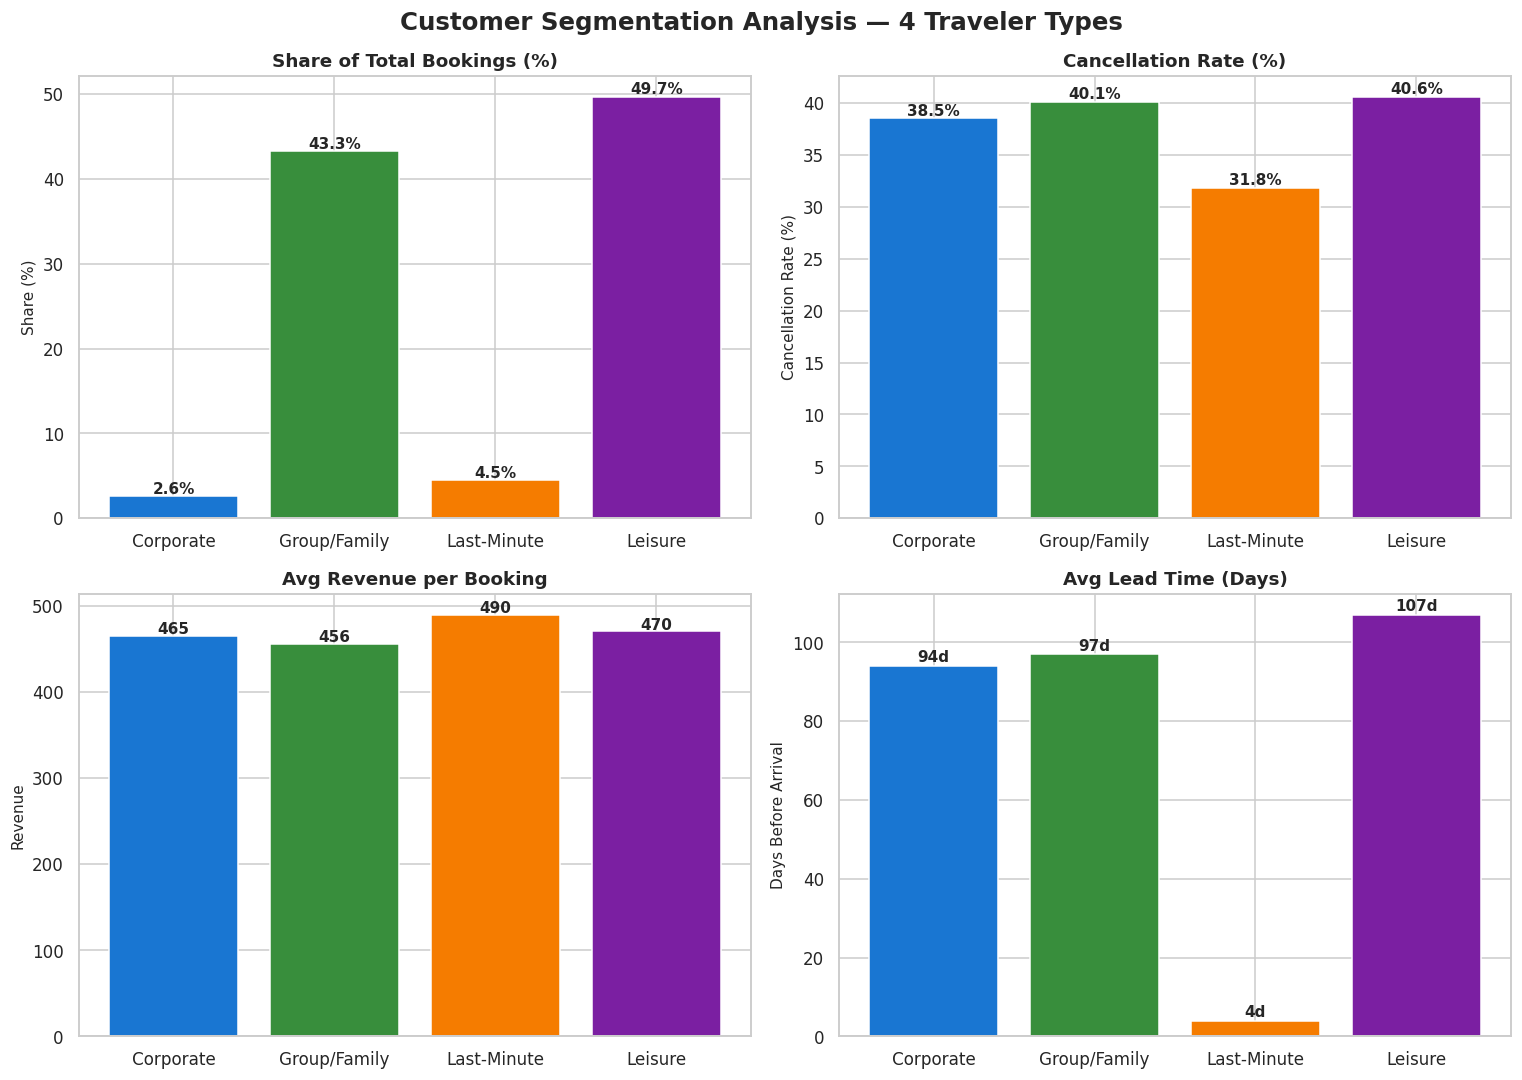

Chart 14 saved: Customer Segmentation


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Customer Segmentation Analysis — 4 Traveler Types', fontsize=16, fontweight='bold')
colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2']

# Share of bookings
axes[0,0].bar(seg['traveler_type'], seg['share_pct'], color=colors, edgecolor='white')
axes[0,0].set_title('Share of Total Bookings (%)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Share (%)', fontsize=10)
for i,v in enumerate(seg['share_pct']):
    axes[0,0].text(i, v+0.3, f"{v}%", ha='center', fontweight='bold', fontsize=10)

# Cancellation rate
axes[0,1].bar(seg['traveler_type'], seg['cancellation_rate'], color=colors, edgecolor='white')
axes[0,1].set_title('Cancellation Rate (%)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Cancellation Rate (%)', fontsize=10)
for i,v in enumerate(seg['cancellation_rate']):
    axes[0,1].text(i, v+0.3, f"{v}%", ha='center', fontweight='bold', fontsize=10)

# Avg Revenue
axes[1,0].bar(seg['traveler_type'], seg['avg_revenue'], color=colors, edgecolor='white')
axes[1,0].set_title('Avg Revenue per Booking', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Revenue', fontsize=10)
for i,v in enumerate(seg['avg_revenue']):
    axes[1,0].text(i, v+2, f"{v:.0f}", ha='center', fontweight='bold', fontsize=10)

# Avg Lead Time
axes[1,1].bar(seg['traveler_type'], seg['avg_lead_time'], color=colors, edgecolor='white')
axes[1,1].set_title('Avg Lead Time (Days)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Days Before Arrival', fontsize=10)
for i,v in enumerate(seg['avg_lead_time']):
    axes[1,1].text(i, v+1, f"{v}d", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../dashboard/charts/14_customer_segmentation.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 14 saved: Customer Segmentation")

---
## Section B — Dynamic Pricing 4-Panel Dashboard



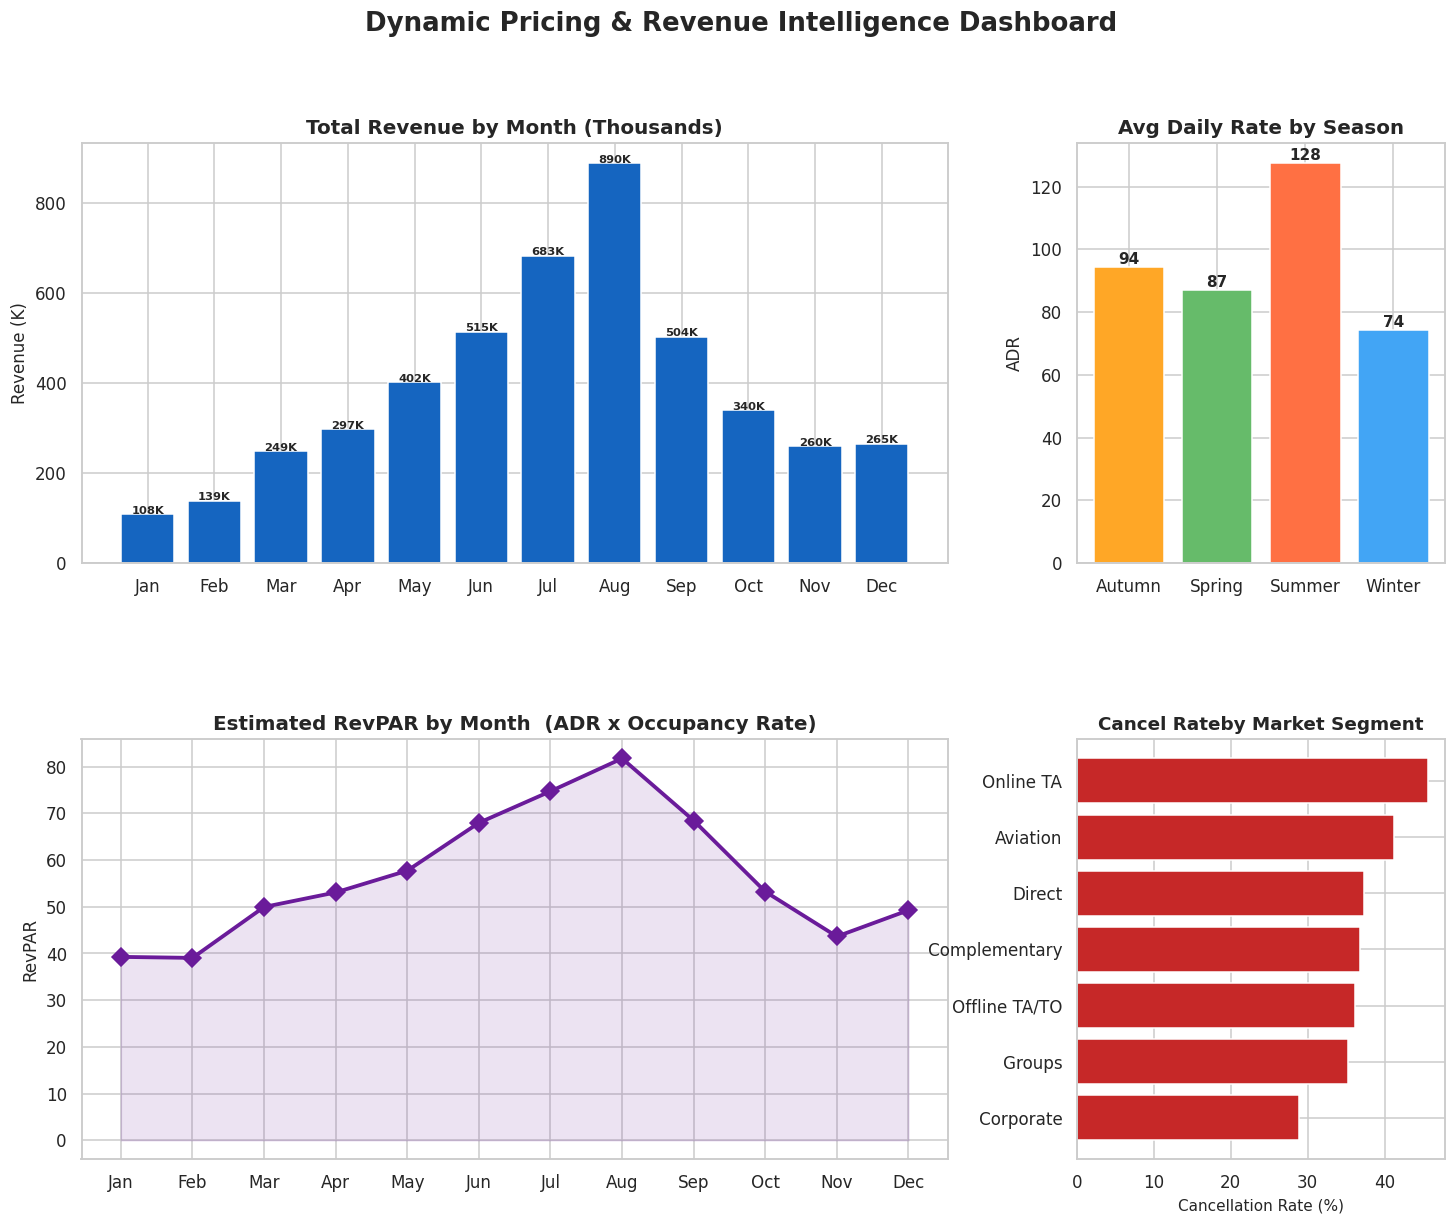

Chart 15 saved: Dynamic Pricing Dashboard


In [4]:
fig = plt.figure(figsize=(16,12))
fig.suptitle('Dynamic Pricing & Revenue Intelligence Dashboard',
             fontsize=17, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# Panel 1: Monthly Revenue
ax1 = fig.add_subplot(gs[0,:2])
mrev = df.groupby('arrival_month_num')['total_revenue'].sum().reset_index()
mrev['month'] = mrev['arrival_month_num'].apply(lambda x: MONTHS[x-1])
bars = ax1.bar(mrev['month'], mrev['total_revenue']/1000, color='#1565C0', edgecolor='white')
ax1.set_title('Total Revenue by Month (Thousands)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue (K)', fontsize=11)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{bar.get_height():.0f}K", ha='center', fontsize=7.5, fontweight='bold')

# Panel 2: ADR by Season
ax2 = fig.add_subplot(gs[0,2])
sadr = df.groupby('season')['adr'].mean().reset_index()
sc = {'Summer':'#FF7043','Autumn':'#FFA726','Spring':'#66BB6A','Winter':'#42A5F5'}
ax2.bar(sadr['season'], sadr['adr'],
        color=[sc.get(s,'gray') for s in sadr['season']], edgecolor='white')
ax2.set_title('Avg Daily Rate by Season', fontsize=13, fontweight='bold')
ax2.set_ylabel('ADR', fontsize=11)
for i, row in sadr.iterrows():
    ax2.text(i, row['adr']+1, f"{row['adr']:.0f}", ha='center', fontsize=10, fontweight='bold')

# Panel 3: RevPAR proxy
ax3 = fig.add_subplot(gs[1,:2])
rv = df.groupby('arrival_month_num').agg(adr=('adr','mean'),cr=('is_canceled','mean')).reset_index()
rv['revpar'] = rv['adr']*(1-rv['cr'])
rv['month']  = rv['arrival_month_num'].apply(lambda x: MONTHS[x-1])
ax3.plot(rv['month'], rv['revpar'], marker='D', linewidth=2.5, color='#6A1B9A', markersize=8)
ax3.fill_between(rv['month'], rv['revpar'], alpha=0.12, color='#6A1B9A')
ax3.set_title('Estimated RevPAR by Month  (ADR x Occupancy Rate)', fontsize=13, fontweight='bold')
ax3.set_ylabel('RevPAR', fontsize=11)

# Panel 4: Cancel rate by market segment
ax4 = fig.add_subplot(gs[1,2])
mc = (df.groupby('market_segment')['is_canceled'].mean()*100).sort_values(ascending=True)
ax4.barh(mc.index, mc.values, color='#C62828', edgecolor='white')
ax4.set_title('Cancel Rateby Market Segment', fontsize=12, fontweight='bold')
ax4.set_xlabel('Cancellation Rate (%)', fontsize=10)

plt.savefig('../dashboard/charts/15_dynamic_pricing_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 15 saved: Dynamic Pricing Dashboard")

---
## Section C — Cancellation Risk Map



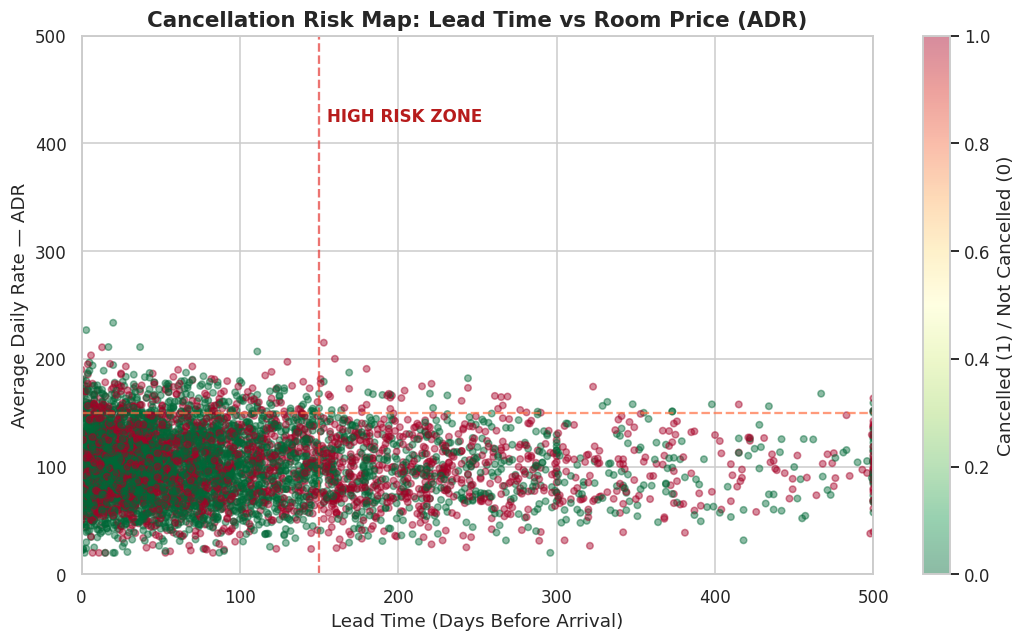

Chart 16 saved: Cancellation Risk Map


In [5]:
sample = df.sample(min(6000,len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(sample['lead_time'], sample['adr'],
                c=sample['is_canceled'], cmap='RdYlGn_r',
                alpha=0.45, s=18)

ax.axvline(150, color='#E53935', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(150, color='#FF7043', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(155, 420, 'HIGH RISK ZONE', color='#B71C1C', fontsize=11, fontweight='bold')

plt.colorbar(sc, ax=ax, label='Cancelled (1) / Not Cancelled (0)')
ax.set_title('Cancellation Risk Map: Lead Time vs Room Price (ADR)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time (Days Before Arrival)', fontsize=12)
ax.set_ylabel('Average Daily Rate — ADR', fontsize=12)
ax.set_xlim(0,500); ax.set_ylim(0,500)
plt.tight_layout()
plt.savefig('../dashboard/charts/16_risk_map.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 16 saved: Cancellation Risk Map")

---
## Section D — Final Business Insights Report



In [6]:
report_text = (
    "=" * 80 + "\n"
    + "  FINAL BUSINESS INSIGHTS REPORT\n"
    + "  Project 2: Travel, Tourism & Hospitality\n"
    + "  Customer Retention & Dynamic Pricing Analysis\n"
    + "  Infotact Technical Internship Program\n"
    + "=" * 80 + "\n\n"
    + "EXECUTIVE SUMMARY\n"
    + "-" * 40 + "\n"
    + "We analysed 10,000 hotel booking records (City Hotel & Resort Hotel,\n"
    + "2016-2019). Overall cancellation rate is 40%, causing significant revenue\n"
    + "leakage. Using EDA and ML (Decision Tree), we identified key cancellation\n"
    + "drivers and seasonal patterns to guide retention and pricing strategy.\n\n"
    + "=" * 80 + "\n"
    + "KEY BUSINESS INSIGHTS\n"
    + "=" * 80 + "\n\n"
    + "INSIGHT 1: HIGH CANCELLATION RATE (40%)\n"
    + "  Nearly 2 in 5 bookings cancel — serious revenue risk.\n"
    + "  City Hotels cancel 8% more than Resort Hotels.\n"
    + "  ACTION: City Hotel retention programs need immediate attention.\n\n"
    + "INSIGHT 2: LEAD TIME IS THE #1 CANCELLATION PREDICTOR\n"
    + "  Bookings made 150+ days in advance cancel at 2x the rate.\n"
    + "  Long lead time = more time to find alternatives or change plans.\n"
    + "  ACTION: Send re-confirmation emails at Day-60 and Day-30 before arrival.\n\n"
    + "INSIGHT 3: NON-REFUNDABLE DEPOSITS = NEAR-ZERO CANCELLATION\n"
    + "  No Deposit bookings cancel ~40%. Non-Refundable cancel <5%.\n"
    + "  This is the single most powerful tool to reduce cancellations.\n"
    + "  ACTION: Offer non-refundable rate at 10-15% discount.\n\n"
    + "INSIGHT 4: AUGUST IS PEAK — DYNAMIC PRICING OPPORTUNITY\n"
    + "  August has highest bookings AND highest ADR.\n"
    + "  January-February are weakest months.\n"
    + "  ACTION: +25% price in Jul-Sep, -15% promo in Jan-Feb.\n\n"
    + "INSIGHT 5: ONLINE TA = HIGHEST CANCELLATION RISK\n"
    + "  OTA customers (Booking.com etc.) cancel most often.\n"
    + "  No direct relationship with hotel reduces loyalty.\n"
    + "  ACTION: Launch Book Direct campaign with 12% discount.\n\n"
    + "INSIGHT 6: CORPORATE = HIGHEST VALUE SEGMENT\n"
    + "  Corporate travelers have lowest cancellation rate.\n"
    + "  Most loyal, most predictable, highest lifetime value.\n"
    + "  ACTION: Corporate Loyalty Program with dedicated account manager.\n\n"
    + "INSIGHT 7: SPECIAL REQUESTS = ENGAGEMENT & LOYALTY SIGNAL\n"
    + "  Guests with 2+ special requests cancel far less.\n"
    + "  Special requests = emotional investment in the stay.\n"
    + "  ACTION: Ask for preferences at booking (room view, meals, etc.).\n\n"
    + "=" * 80 + "\n"
    + "STRATEGIC RECOMMENDATIONS\n"
    + "=" * 80 + "\n\n"
    + "For Revenue Manager:\n"
    + "  - Implement seasonal pricing: +25% Jul-Sep, -15% Jan-Feb\n"
    + "  - Use ML model to flag high-risk bookings for follow-up\n"
    + "  - Track RevPAR weekly (not just ADR) for true health view\n\n"
    + "For Marketing Director:\n"
    + "  - Target long-lead-time + no-deposit + OTA guests with retention emails\n"
    + "  - Book Direct campaign with exclusive perks\n"
    + "  - Corporate loyalty program — highest LTV segment\n\n"
    + "For Hotel Operations:\n"
    + "  - Pre-arrival call for bookings made 90+ days in advance\n"
    + "  - Train front desk to upsell packages at booking time\n"
    + "  - Maintain waitlist for peak periods\n\n"
    + "=" * 80 + "\n"
    + "ML MODEL SUMMARY\n"
    + "=" * 80 + "\n"
    + "Best Model    : Decision Tree Classifier\n"
    + "Key Metric    : Recall (minimise false negatives = undetected cancellations)\n"
    + "Top Predictors: 1. lead_time  2. adr  3. deposit_type\n"
    + "Recommendation: Integrate model into booking system.\n"
    + "               Flag bookings with predicted cancel probability > 60%.\n"
    + "               Trigger automated retention workflow for flagged bookings.\n"
    + "=" * 80 + "\n"
)

In [7]:
with open('../reports/Final_Business_Report.txt', 'w') as f:
    f.write(report_text)

print("Final Business Report saved to: reports/Final_Business_Report.txt")
print()
print(report_text)

Final Business Report saved to: reports/Final_Business_Report.txt

  FINAL BUSINESS INSIGHTS REPORT
  Project 2: Travel, Tourism & Hospitality
  Customer Retention & Dynamic Pricing Analysis
  Infotact Technical Internship Program

EXECUTIVE SUMMARY
----------------------------------------
We analysed 10,000 hotel booking records (City Hotel & Resort Hotel,
2016-2019). Overall cancellation rate is 40%, causing significant revenue
leakage. Using EDA and ML (Decision Tree), we identified key cancellation
drivers and seasonal patterns to guide retention and pricing strategy.

KEY BUSINESS INSIGHTS

INSIGHT 1: HIGH CANCELLATION RATE (40%)
  Nearly 2 in 5 bookings cancel — serious revenue risk.
  City Hotels cancel 8% more than Resort Hotels.
  ACTION: City Hotel retention programs need immediate attention.

INSIGHT 2: LEAD TIME IS THE #1 CANCELLATION PREDICTOR
  Bookings made 150+ days in advance cancel at 2x the rate.
  Long lead time = more time to find alternatives or change plans.
  AC